In [1]:
import torch
import torch.nn as nn                                              # impoting libraries
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()                                 # image to tensor

In [3]:
train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.80MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.3MB/s]


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


transform = transforms.ToTensor()


train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)

print(len(train_dataset))
image, label = train_dataset[0]
print(label)
print(image.shape)

60000
5
torch.Size([1, 28, 28])


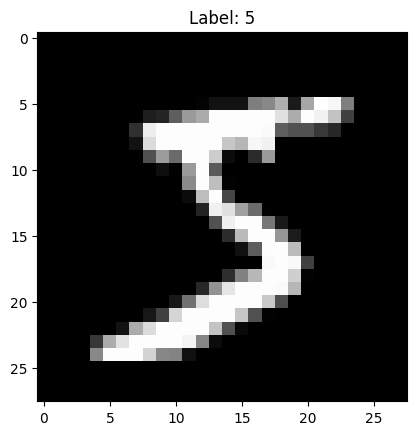

In [5]:
plt.imshow(image.squeeze(),cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [6]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
images,labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels)

torch.Size([64, 1, 28, 28])
torch.Size([64])
tensor([4, 2, 8, 2, 5, 3, 9, 3, 6, 5, 6, 2, 1, 5, 3, 3, 4, 3, 0, 0, 9, 9, 8, 9,
        2, 8, 9, 3, 8, 1, 8, 7, 1, 2, 1, 2, 2, 9, 4, 5, 4, 5, 3, 6, 1, 3, 8, 9,
        2, 6, 9, 8, 1, 9, 7, 7, 9, 7, 3, 0, 0, 2, 3, 1])


In [7]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
      nn.Conv2d(1,32,kernel_size = 3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Flatten(),
      nn.Linear(5408,128),
      nn.ReLU(),
      nn.Linear(128,10)
    )
  def forward(self,x):
    return self.network(x)



In [8]:
model = CNN()
outputs = model(images)
print(outputs.shape)

torch.Size([64, 10])


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [12]:
for epoch in range (5):
  for images ,labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss =criterion(outputs , labels)
    loss.backward()
    optimizer.step()
    print(f"epoch{epoch+1},loss:{loss.item():4f}")

epoch1,loss:0.067676
epoch1,loss:0.019237
epoch1,loss:0.007755
epoch1,loss:0.046592
epoch1,loss:0.012755
epoch1,loss:0.009572
epoch1,loss:0.001697
epoch1,loss:0.016161
epoch1,loss:0.008402
epoch1,loss:0.067427
epoch1,loss:0.007509
epoch1,loss:0.012277
epoch1,loss:0.009823
epoch1,loss:0.011102
epoch1,loss:0.005496
epoch1,loss:0.003038
epoch1,loss:0.011490
epoch1,loss:0.023996
epoch1,loss:0.009221
epoch1,loss:0.003124
epoch1,loss:0.099825
epoch1,loss:0.001753
epoch1,loss:0.031814
epoch1,loss:0.003994
epoch1,loss:0.018918
epoch1,loss:0.026553
epoch1,loss:0.004469
epoch1,loss:0.003691
epoch1,loss:0.059148
epoch1,loss:0.009670
epoch1,loss:0.004107
epoch1,loss:0.004925
epoch1,loss:0.025599
epoch1,loss:0.009938
epoch1,loss:0.045964
epoch1,loss:0.111469
epoch1,loss:0.001616
epoch1,loss:0.004107
epoch1,loss:0.011932
epoch1,loss:0.005255
epoch1,loss:0.006640
epoch1,loss:0.083621
epoch1,loss:0.001942
epoch1,loss:0.047663
epoch1,loss:0.007060
epoch1,loss:0.003072
epoch1,loss:0.010837
epoch1,loss:0

In [19]:
# testing phase
test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=transform)
test_loader= DataLoader(test_dataset,batch_size=64,shuffle=True)
model.eval()
correct = 0
total =0
with torch.no_grad():
 for images,labels in test_loader:
  outputs = model(images)
  _,predicted = torch.max(outputs,1)
  total += labels.size(0)
  correct += (predicted == labels).sum().item()
  accuracy = 100 * correct/total
  print(f"accuracy:{accuracy:.2f}%")

accuracy:100.00%
accuracy:99.22%
accuracy:98.96%
accuracy:99.22%
accuracy:99.38%
accuracy:99.22%
accuracy:98.88%
accuracy:99.02%
accuracy:99.13%
accuracy:99.22%
accuracy:99.15%
accuracy:98.83%
accuracy:98.68%
accuracy:98.77%
accuracy:98.54%
accuracy:98.54%
accuracy:98.35%
accuracy:98.35%
accuracy:98.36%
accuracy:98.44%
accuracy:98.44%
accuracy:98.22%
accuracy:98.23%
accuracy:98.24%
accuracy:98.31%
accuracy:98.32%
accuracy:98.38%
accuracy:98.38%
accuracy:98.44%
accuracy:98.49%
accuracy:98.49%
accuracy:98.44%
accuracy:98.44%
accuracy:98.44%
accuracy:98.44%
accuracy:98.44%
accuracy:98.44%
accuracy:98.48%
accuracy:98.44%
accuracy:98.44%
accuracy:98.48%
accuracy:98.51%
accuracy:98.47%
accuracy:98.51%
accuracy:98.51%
accuracy:98.51%
accuracy:98.54%
accuracy:98.57%
accuracy:98.60%
accuracy:98.56%
accuracy:98.56%
accuracy:98.53%
accuracy:98.53%
accuracy:98.55%
accuracy:98.55%
accuracy:98.52%
accuracy:98.52%
accuracy:98.52%
accuracy:98.54%
accuracy:98.54%
accuracy:98.57%
accuracy:98.54%
accurac

In [20]:
# saving the model
torch.save(model.state_dict(),"cnn_model.pth")

In [23]:
#load the model
model = CNN()
model.load_state_dict(torch.load("cnn_model.pth"))
model.eval()

CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=5408, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [51]:
dataiter=iter(test_loader)
images,labels = next(dataiter)
image = images[0]
label = labels[0]
image = image.unsqueeze(0)
with torch.no_grad():
 output = model(image)
_,predicted = torch.max(output,1)
print("actual label:",label.item())
print("pridected label:",predicted.item())

actual label: 3
pridected label: 3
